## ANALYSE DES RETOURS PORTFOLIO

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/ratings_rows.csv")

df.head()

,id,rating,comment,created_at
0,146a26dc-dd4e-4a32-90ca-3a5a901e479a,4,NaN,2026-08-09 00:12:11.523324+00
1,5e3b2a8b-ce9e-4423-80ae-11c712cac551,4,je kiffe grave,2026-08-13 11:40:07.581059+00
2,6165f915-748a-4344-9eed-3a3c17af50c8,3,j'apprécie ta section experience,2026-08-09 00:13:24.715709+00
3,9e7b43a5-38e2-48d1-8f1b-71ccbb1fa326,4,NaN,2026-08-08 23:00:58.666604+00
4,a3d46fd7-0e9d-4f59-8a12-2055a0e1bd42,4,NaN,2026-08-13 12:44:30.429572+00


In [7]:
df.shape

(6, 4)

In [8]:
df.info

<bound method DataFrame.info of                                      id  rating  \
0  146a26dc-dd4e-4a32-90ca-3a5a901e479a       4   
1  5e3b2a8b-ce9e-4423-80ae-11c712cac551       4   
2  6165f915-748a-4344-9eed-3a3c17af50c8       3   
3  9e7b43a5-38e2-48d1-8f1b-71ccbb1fa326       4   
4  a3d46fd7-0e9d-4f59-8a12-2055a0e1bd42       4   
5  ea000ed7-9c87-483a-9417-51356a12f7ee       2   

                            comment                     created_at  
0                               NaN  2026-08-09 00:12:11.523324+00  
1                    je kiffe grave  2026-08-13 11:40:07.581059+00  
2  j'apprécie ta section experience  2026-08-09 00:13:24.715709+00  
3                               NaN  2026-08-08 23:00:58.666604+00  
4                               NaN  2026-08-13 12:44:30.429572+00  
5                               NaN  2026-08-09 00:12:42.252879+00  >

In [9]:
# tous les calcules arrithmetique
df.describe()

,rating
count,6.00000
mean,3.50000
std,0.83666
min,2.00000
25%,3.25000
50%,4.00000
75%,4.00000
max,4.00000


In [10]:
#verification de zone avec valeurs manquantes
df.isnull().sum()

id            0
rating        0
comment       4
created_at    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["rating"].value_counts().sort_index()

rating
2    1
3    1
4    4
Name: count, dtype: int64

In [13]:
df["rating"].mean()

np.float64(3.5)

In [14]:
df["rating"].median()

np.float64(4.0)

In [15]:
df["rating"].std()

np.float64(0.8366600265340756)

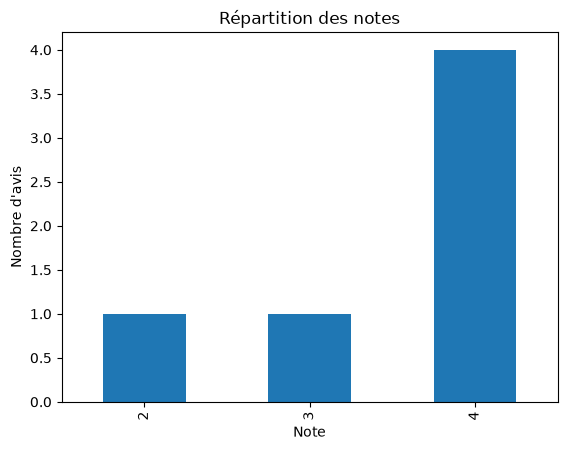

In [16]:
import matplotlib.pyplot as plt

df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Répartition des notes")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
plt.show()

In [17]:
df["created_at"].dtype

<StringDtype(storage='python', na_value=nan)>

In [18]:
df["created_at"] = pd.to_datetime(df["created_at"])

In [19]:
df["created_at"].describe()

count                                   6
mean     2026-08-10 12:00:39.194858+00:00
min      2026-08-08 23:00:58.666604+00:00
25%      2026-08-09 00:12:19.205712+00:00
50%      2026-08-09 00:13:03.484294+00:00
75%      2026-08-12 08:48:26.864721+00:00
max      2026-08-13 12:44:30.429572+00:00
Name: created_at, dtype: object

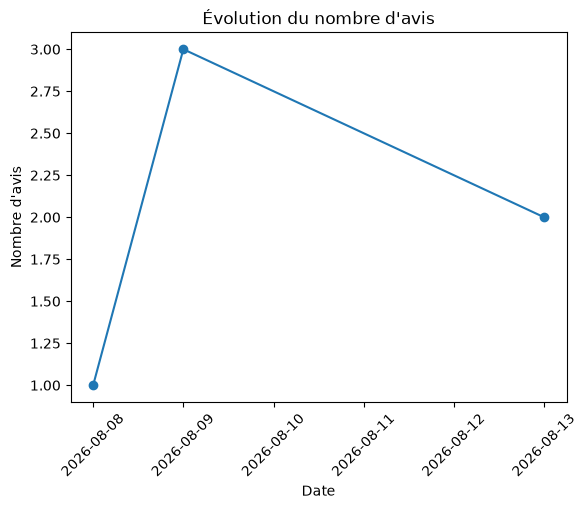

In [20]:
avis_par_date = df["created_at"].dt.date.value_counts().sort_index()

avis_par_date.plot(kind="line", marker="o")

plt.title("Évolution du nombre d'avis")
plt.xlabel("Date")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.show()

In [21]:
df[df["comment"].notna()][["rating", "comment"]]

,rating,comment
1,4,je kiffe grave
2,3,j'apprécie ta section experience


In [22]:
df["rating"].value_counts().sort_index()

rating
2    1
3    1
4    4
Name: count, dtype: int64

In [23]:
df[["rating", "comment"]].sort_values("rating")

,rating,comment
5,2,NaN
2,3,j'apprécie ta section experience
1,4,je kiffe grave
0,4,NaN
3,4,NaN
4,4,NaN


In [24]:
df["created_at"] = pd.to_datetime(df["created_at"])

df["created_at"].dt.date.value_counts().sort_index()

created_at
2026-08-08    1
2026-08-09    3
2026-08-13    2
Name: count, dtype: int64

In [25]:
print("Moyenne :", df["rating"].mean())
print("Médiane :", df["rating"].median())
print("Écart-type :", df["rating"].std())
print("Minimum :", df["rating"].min())
print("Maximum :", df["rating"].max())

Moyenne : 3.5
Médiane : 4.0
Écart-type : 0.8366600265340756
Minimum : 2
Maximum : 4


In [26]:
df["rating"].value_counts().sort_index()

rating
2    1
3    1
4    4
Name: count, dtype: int64

In [27]:
df[df["comment"].notna()][["rating", "comment"]]

,rating,comment
1,4,je kiffe grave
2,3,j'apprécie ta section experience


In [28]:
df["created_at"] = pd.to_datetime(df["created_at"])

print(df["created_at"].min())
print(df["created_at"].max())

2026-08-08 23:00:58.666604+00:00
2026-08-13 12:44:30.429572+00:00


In [29]:
avis_par_date = df.groupby(df["created_at"].dt.date).size()

avis_par_date

created_at
2026-08-08    1
2026-08-09    3
2026-08-13    2
dtype: int64

In [30]:
# Calcul de la note moyenne par date
moyenne_par_date = df.groupby(df["created_at"].dt.date)["rating"].mean()

print(moyenne_par_date)

created_at
2026-08-08    4.0
2026-08-09    3.0
2026-08-13    4.0
Name: rating, dtype: float64


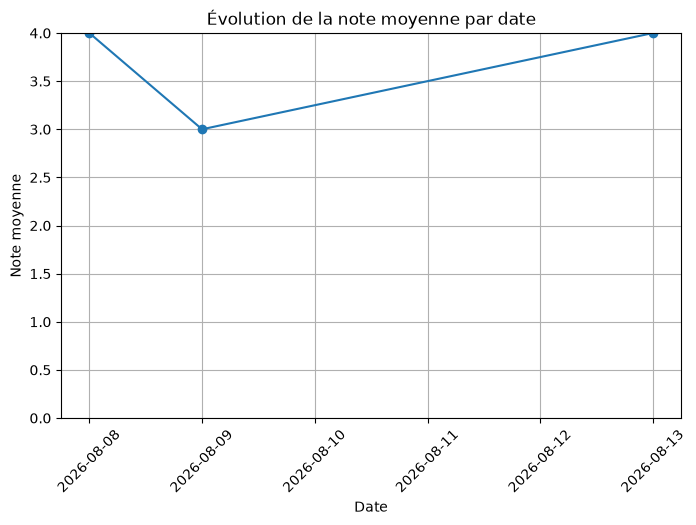

In [31]:
import matplotlib.pyplot as plt

moyenne_par_date.plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Évolution de la note moyenne par date")
plt.xlabel("Date")
plt.ylabel("Note moyenne")
plt.ylim(0, 4)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [32]:
print(moyenne_par_date)

created_at
2026-08-08    4.0
2026-08-09    3.0
2026-08-13    4.0
Name: rating, dtype: float64
